In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

Obtain the UVB grid from FG20

In [4]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [5]:
z_test = 1

In [6]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [7]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [8]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [9]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [10]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [11]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [12]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

Make plots to test interpolation

In [13]:
log_hdens_plot = np.arange(log_hdens_min, log_hdens_max+.1, .1)
logU_plot = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_plot))

In [14]:
logN_HI_test = 15.
plot_log_metals = np.arange(-3, 2, 1, dtype='float')

In [15]:
logN_HI_idx = np.where(logN_HI_arr==logN_HI_test)[0][0]

In [16]:
logN_HI_idx

12

In [17]:
np.where(log_metals_arr==1)

(array([16]),)

/opt/anaconda3/lib/python3.9/site-packages/matplotlib/ticker.py:2789: RuntimeWarning: invalid value encountered in log10
  majorstep_no_exponent = 10 ** (np.log10(majorstep) % 1)
/opt/anaconda3/lib/python3.9/site-packages/matplotlib/ticker.py:2789: RuntimeWarning: invalid value encountered in double_scalars
  majorstep_no_exponent = 10 ** (np.log10(majorstep) % 1)


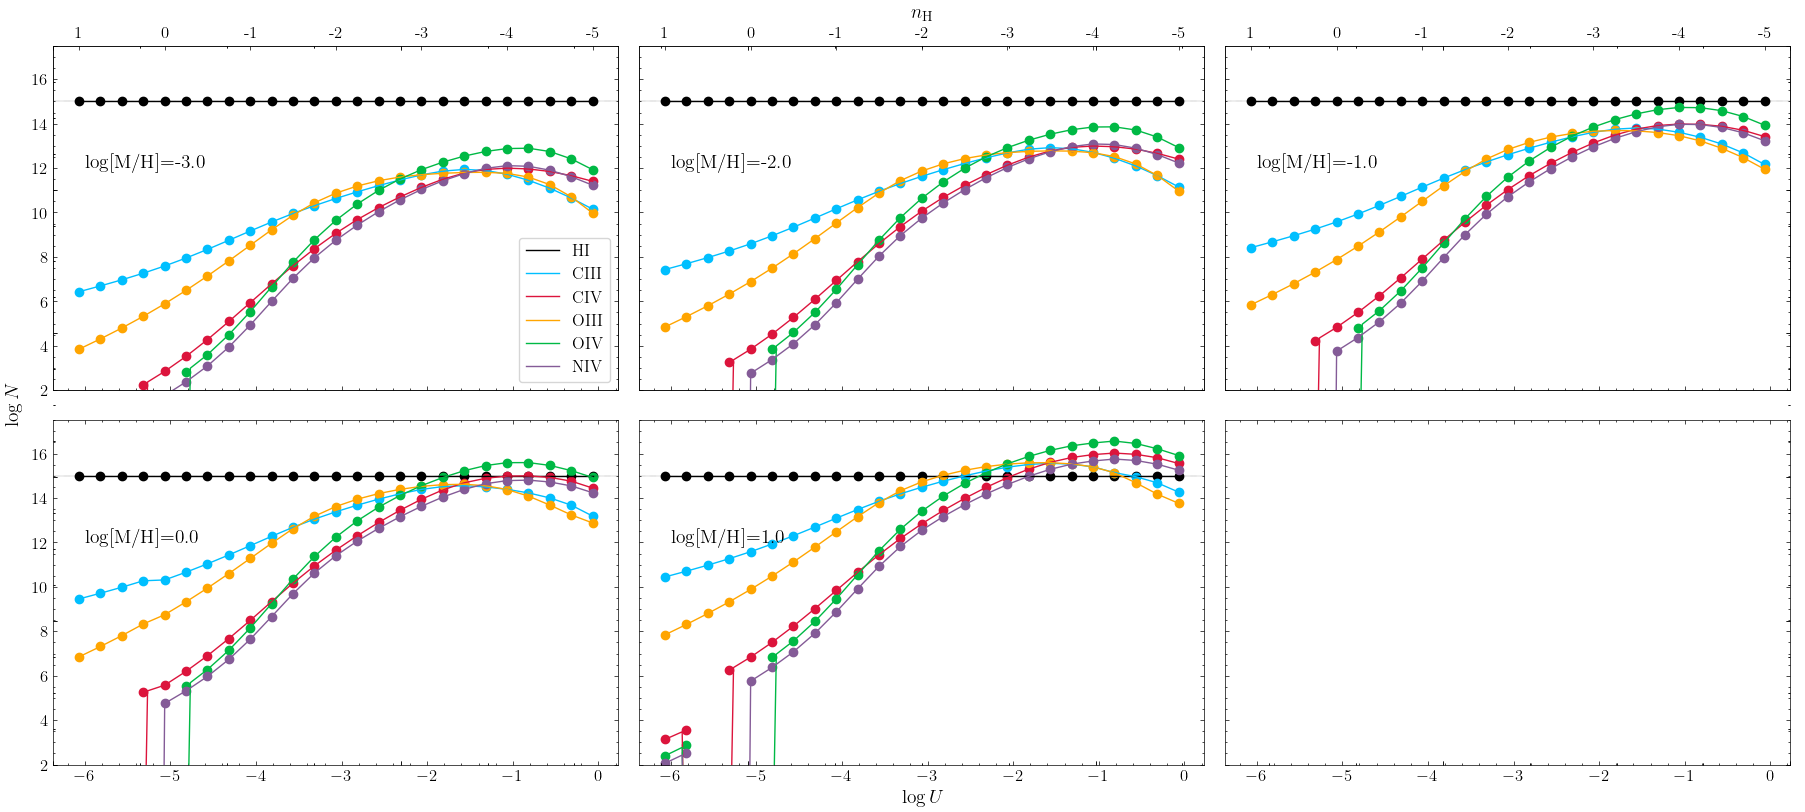

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(6*3,4*2), sharex=True, sharey=True)

for i in range(len(plot_log_metals)):
    
    log_m = plot_log_metals[i]
    log_m_idx = np.where(log_metals_arr==log_m)[0][0]
        
    ax = axes[i//3, i%3]
    
    ax.text(x=-6,y=12,s=r'$\log$[M/H]={}'.format(log_m))
    
    # Reference line
    ax.axhline(logN_HI_test, linestyle=':', lw=.3)
    
    # Plotting points
    plot_points = [[logN_HI_test, log_hdens, log_m] for log_hdens in log_hdens_plot]
    
    # Plot sampled column densities
    ax.scatter(logU_arr, species_logN_samples['#column density H'][logN_HI_idx,:,log_m_idx])
    ax.scatter(logU_arr, species_logN_samples['C+2'][logN_HI_idx,:,log_m_idx])
    ax.scatter(logU_arr, species_logN_samples['C+3'][logN_HI_idx,:,log_m_idx])
    ax.scatter(logU_arr, species_logN_samples['O+2'][logN_HI_idx,:,log_m_idx])
    ax.scatter(logU_arr, species_logN_samples['O+3'][logN_HI_idx,:,log_m_idx])
    ax.scatter(logU_arr, species_logN_samples['N+3'][logN_HI_idx,:,log_m_idx])
    
    # Plot interpolated column densities
    ax.plot(logU_plot, species_logN_interp['#column density H'](plot_points), label='HI')
    ax.plot(logU_plot, species_logN_interp['C+2'](plot_points), label='CIII')
    ax.plot(logU_plot, species_logN_interp['C+3'](plot_points), label='CIV')
    ax.plot(logU_plot, species_logN_interp['O+2'](plot_points), label='OIII')
    ax.plot(logU_plot, species_logN_interp['O+3'](plot_points), label='OIV')
    ax.plot(logU_plot, species_logN_interp['N+3'](plot_points), label='NIV')
    
    ax.set_ylim(2,17.5)

    if i//3 == 0:
        ax_copy = ax.twiny() # https://stackoverflow.com/questions/10514315/how-to-add-a-second-x-axis-in-matplotlib
        new_ticks = np.arange(-5,2,1, dtype='float')
        ax_copy.set_xlim(ax.get_xlim())
        ax_copy.set_xticks(np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, np.power(10, new_ticks))))
        ax_copy.set_xticklabels(np.int_(new_ticks))
    
    if i==0:
        ax.legend(loc='lower right')

plt.tight_layout()

ax_label = fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', top='off', bottom='off', left='off', right='off')

ax_label.set_xlabel(r'$\log U$')
ax_label.set_ylabel(r'$\log N$')

ax_copy_label = fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', top='off', bottom='off', left='off', right='off')

ax_copy_label.set_xlabel(r'$n_\mathrm{H}$', labelpad=20)
ax_copy_label.xaxis.set_label_position('top')

Make plots to test deviation from samples

In [19]:
log_hdens_plot = np.arange(log_hdens_min, log_hdens_max+.1, .1)
logU_plot = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_plot))

In [20]:
logN_HI_test = 15.40
plot_log_metals = np.arange(-3, 2, 1, dtype='float')

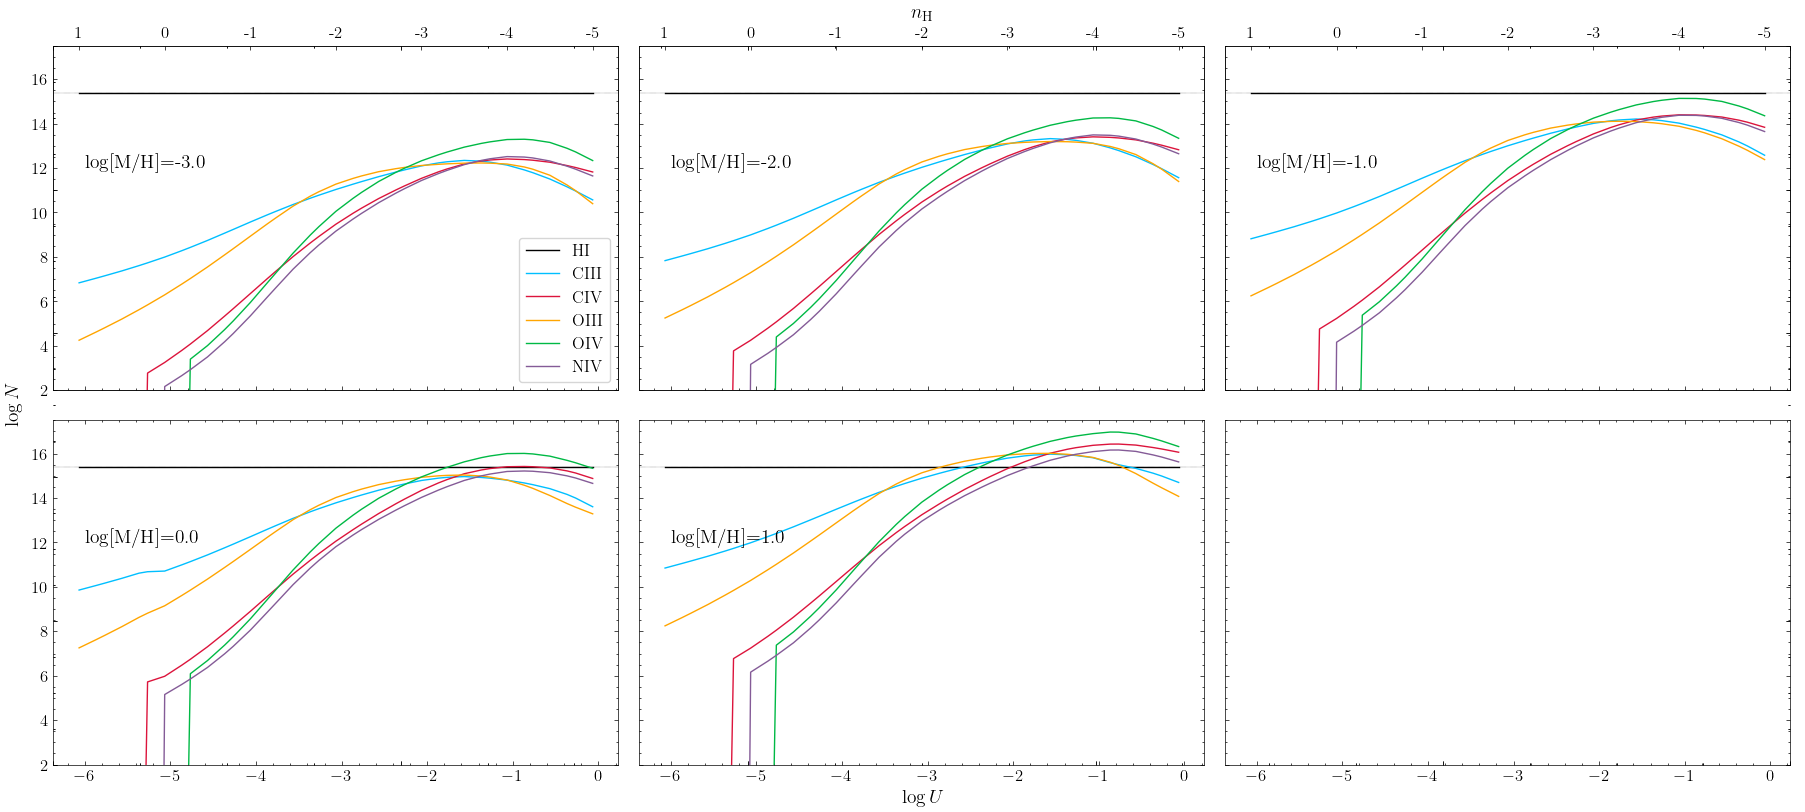

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(6*3,4*2), sharex=True, sharey=True)

for i in range(len(plot_log_metals)):
    
    log_m = plot_log_metals[i]
        
    ax = axes[i//3, i%3]
    
    ax.text(x=-6,y=12,s=r'$\log$[M/H]={}'.format(log_m))
    
    # Reference line
    ax.axhline(logN_HI_test, linestyle=':', lw=.3)
    
    # Plotting points
    plot_points = [[logN_HI_test, log_hdens, log_m] for log_hdens in log_hdens_plot]
    
    # Plot interpolated column densities
    ax.plot(logU_plot, species_logN_interp['#column density H'](plot_points), label='HI')
    ax.plot(logU_plot, species_logN_interp['C+2'](plot_points), label='CIII')
    ax.plot(logU_plot, species_logN_interp['C+3'](plot_points), label='CIV')
    ax.plot(logU_plot, species_logN_interp['O+2'](plot_points), label='OIII')
    ax.plot(logU_plot, species_logN_interp['O+3'](plot_points), label='OIV')
    ax.plot(logU_plot, species_logN_interp['N+3'](plot_points), label='NIV')
    
    ax.set_ylim(2,17.5)

    if i//3 == 0:
        ax_copy = ax.twiny() # https://stackoverflow.com/questions/10514315/how-to-add-a-second-x-axis-in-matplotlib
        new_ticks = np.arange(-5,2,1, dtype='float')
        ax_copy.set_xlim(ax.get_xlim())
        ax_copy.set_xticks(np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, np.power(10, new_ticks))))
        ax_copy.set_xticklabels(np.int_(new_ticks))
    
    if i==0:
        ax.legend(loc='lower right')

plt.tight_layout()

ax_label = fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', top='off', bottom='off', left='off', right='off')

ax_label.set_xlabel(r'$\log U$')
ax_label.set_ylabel(r'$\log N$')

ax_copy_label = fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', top='off', bottom='off', left='off', right='off')

ax_copy_label.set_xlabel(r'$n_\mathrm{H}$', labelpad=20)
ax_copy_label.xaxis.set_label_position('top')